# Build new inference index

This notebook shows how to build an Index compatible with `opr.inference.index`.


In [1]:
from pathlib import Path
from IPython.display import display

from torchvision import transforms as T
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn, Tensor
import open3d as o3d
#import MinkowskiEngine as ME
from PIL import Image


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


The example below is for SberRobotics Office dataset.

- `map1` - database, sampled with `DIST_THRESH` OR `ANGLE_THRESH_DEG`
- The rest of the maps will be the queries

In [2]:
root_data_dir = Path(
    "/mnt/external_usb_hdd/6YL/Datasets/3RScan/"
)
assert root_data_dir.exists(), f"Path {root_data_dir} does not exist"



In [3]:
from torchvision.transforms import functional as F

image_transform_fn = T.Compose([
    T.ToTensor(),
    T.Lambda(lambda x: F.rotate(x, -90)),  # 90 degrees clockwise
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    T.Resize([322, 322], antialias=True),
])

## load poses

In [4]:
from pathlib import Path
import pandas as pd

def make_image_filenames_df(directory: str | Path,
                            sequence_dir_name: str = "sequence"):
    """
    Create DataFrame with image filenames from:
        directory/some_subdir/sequence/

    Returns
    -------
    df : pd.DataFrame
        All rows.
    df_even : pd.DataFrame
        Rows where is_even == True.
    df_odd : pd.DataFrame
        Rows where is_even == False.
    """
    directory = Path(directory)
    image_patterns = ("*.color.jpg", "*.color.jpeg", "*.color.png", "*.color.bmp", "*.color.gif", "*.color.webp", "*.color.tiff")

    sequence_dirs = [p for p in directory.glob(f"*/{sequence_dir_name}") if p.is_dir()]

    files: list[Path] = []
    for seq_dir in sequence_dirs:
        for pattern in image_patterns:
            files.extend(seq_dir.glob(pattern))

    df = pd.DataFrame(
        {
            "filename": [p.name for p in files],
            "path": [str(p.resolve()) for p in files],
            "scene": [p.parent.parent.name for p in files],  # renamed column
        }
    )

    # Enumerate scenes (0-based IDs)
    df["scene_id"], _ = pd.factorize(df["scene"])

    # Sort by scene_id then filename
    df = df.sort_values(["scene_id", "filename"]).reset_index(drop=True)

    # Even/odd flag after sorting
    df["is_even"] = df.index % 2 == 0

    # Split by bool column
    df_even = df[df["is_even"]].reset_index(drop=True)
    df_odd = df[~df["is_even"]].reset_index(drop=True)

    return df, df_even, df_odd

In [6]:
full_df, db_df, q_df = make_image_filenames_df(root_data_dir / "scenes")
display(db_df.head())
display(db_df.tail())

index_dir = root_data_dir
cuted_df = db_df.iloc[:10000]

,filename,path,scene,scene_id,is_even
0,frame-000000.color.jpg,/mnt/external_usb_hdd/6YL/Datasets/3RScan/scen...,c92fb570-f771-2064-8700-e44ec1355c49,0,True
1,frame-000001.color.jpg,/mnt/external_usb_hdd/6YL/Datasets/3RScan/scen...,c92fb570-f771-2064-8700-e44ec1355c49,0,True
2,frame-000002.color.jpg,/mnt/external_usb_hdd/6YL/Datasets/3RScan/scen...,c92fb570-f771-2064-8700-e44ec1355c49,0,True
3,frame-000003.color.jpg,/mnt/external_usb_hdd/6YL/Datasets/3RScan/scen...,c92fb570-f771-2064-8700-e44ec1355c49,0,True
4,frame-000004.color.jpg,/mnt/external_usb_hdd/6YL/Datasets/3RScan/scen...,c92fb570-f771-2064-8700-e44ec1355c49,0,True


,filename,path,scene,scene_id,is_even
363550,frame-000116.color.jpg,/mnt/external_usb_hdd/6YL/Datasets/3RScan/scen...,6a360523-fa53-2915-9506-4b95fa02cc56,1480,True
363551,frame-000117.color.jpg,/mnt/external_usb_hdd/6YL/Datasets/3RScan/scen...,6a360523-fa53-2915-9506-4b95fa02cc56,1480,True
363552,frame-000118.color.jpg,/mnt/external_usb_hdd/6YL/Datasets/3RScan/scen...,6a360523-fa53-2915-9506-4b95fa02cc56,1480,True
363553,frame-000000.color.jpg,/mnt/external_usb_hdd/6YL/Datasets/3RScan/scen...,ba6fda98-a4c1-2dca-8230-bce60f5a0f85,1481,True
363554,frame-000001.color.jpg,/mnt/external_usb_hdd/6YL/Datasets/3RScan/scen...,ba6fda98-a4c1-2dca-8230-bce60f5a0f85,1481,True


## cut poses by images len (optional)

In [ ]:
if num_files < len(db_map_df):
    db_map_df = db_map_df.iloc[:num_files]

display(db_map_df.tail())


,timestamp,front_cam_ts,back_cam_ts,lidar_ts,x,y,z,qx,qy,qz,qw
249,1698264849718639616,1698264849676965759,1698264849689958331,1698264849722924313,2.660992,2.294300,99.866778,-0.024562,0.022925,0.607234,-0.793813
250,1698264851028064512,1698264850990813971,1698264850985596943,1698264851032721570,2.853010,1.271028,99.926578,-0.018994,0.013818,0.769123,-0.638669
251,1698264852642632704,1698264852640794484,1698264852612610043,1698264852646716773,2.486120,0.393792,99.996949,-0.022611,0.017190,0.975104,-0.219922
252,1698264854963774720,1698264854908024867,1698264854953993503,1698264854969959146,1.486615,0.207877,100.089107,-0.022693,0.022959,0.999041,0.029591
253,1698264858394072576,1698264858432181045,1698264858408129041,1698264858398401671,0.442454,0.300887,100.167926,-0.019875,0.017961,0.999511,0.016124


## filter poses (optional)

In [ ]:
def filter_db_by_spatial_and_angular_thresholds(
    df: pd.DataFrame,
    dist_thresh: float,
    angle_thresh_deg: float,
    position_columns: list[str] = ["x", "y", "z"],
    quaternion_columns: list[str] = ["qx", "qy", "qz", "qw"],
    start_with_first: bool = True,
) -> pd.DataFrame:
    """Filter frames by spatial and angular thresholds.

    Samples frames sequentially from ``df``. A frame is selected if it is farther
    than ``dist_thresh`` from all currently selected frames. Otherwise (if it is
    spatially close), it is selected only if the angular distance to the closest
    selected frame exceeds ``angle_thresh_deg``.

    Args:
        df: DataFrame with at least the position and quaternion columns.
        dist_thresh: Minimum Euclidean distance (meters) to accept unconditionally.
        angle_thresh_deg: Angular distance threshold in degrees when spatially close.
        position_columns: Names of position columns in order [x, y, z].
        quaternion_columns: Names of quaternion columns in order [qx, qy, qz, qw].
        start_with_first: Whether to force-include the first frame to seed selection.

    Returns:
        A new DataFrame containing the sampled frames in their original order.
    """
    # Validate columns
    required_cols = position_columns + quaternion_columns
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    if len(df) == 0:
        return df.copy()

    positions = df[position_columns].to_numpy(dtype=float, copy=True)
    quaternions = df[quaternion_columns].to_numpy(dtype=float, copy=True)

    selected_indices: list[int] = []

    def _normalize_quaternion(q: np.ndarray) -> np.ndarray:
        """Return unit quaternion; if zero-norm, return input."""
        norm = np.linalg.norm(q)
        return q / norm if norm > 0 else q

    def _quaternion_angle_diff_deg(q1: np.ndarray, q2: np.ndarray) -> float:
        """Compute minimal angular difference between two quaternions in degrees."""
        q1n = _normalize_quaternion(q1)
        q2n = _normalize_quaternion(q2)
        dot = float(np.clip(np.abs(np.dot(q1n, q2n)), -1.0, 1.0))
        angle_rad = 2.0 * np.arccos(dot)
        return float(np.degrees(angle_rad))

    if start_with_first:
        selected_indices.append(0)

    selected_positions = (
        positions[selected_indices]
        if selected_indices
        else np.empty((0, positions.shape[1]), dtype=float)
    )
    selected_quaternions = (
        quaternions[selected_indices]
        if selected_indices
        else np.empty((0, quaternions.shape[1]), dtype=float)
    )

    start_i = 1 if start_with_first else 0
    for i in range(start_i, len(df)):
        pos_i = positions[i]
        quat_i = quaternions[i]

        if selected_positions.shape[0] == 0:
            selected_indices.append(i)
            selected_positions = np.vstack([selected_positions, pos_i])
            selected_quaternions = np.vstack([selected_quaternions, quat_i])
            continue

        dists = np.linalg.norm(selected_positions - pos_i, axis=1)
        nearest_sel_idx = int(np.argmin(dists))
        min_dist = float(dists[nearest_sel_idx])

        if min_dist > dist_thresh:
            should_select = True
        else:
            ang_deg = _quaternion_angle_diff_deg(quat_i, selected_quaternions[nearest_sel_idx])
            should_select = ang_deg > angle_thresh_deg

        if should_select:
            selected_indices.append(i)
            selected_positions = np.vstack([selected_positions, pos_i])
            selected_quaternions = np.vstack([selected_quaternions, quat_i])

    filtered_df = df.iloc[selected_indices]
    print(
        f"Selected {len(filtered_df)} / {len(df)} frames "
        f"({len(filtered_df) / max(1, len(df)):.1%})."
    )
    return filtered_df


In [ ]:
filtered_df = filter_db_by_spatial_and_angular_thresholds(
    db_map_df,
    dist_thresh=DIST_THRESH,
    angle_thresh_deg=ANGLE_THRESH_DEG,
)
display(filtered_df.head())
display(filtered_df.tail())

Selected 254 / 254 frames (100.0%).


,timestamp,front_cam_ts,back_cam_ts,lidar_ts,x,y,z,qx,qy,qz,qw
0,1698264507070846464,1698264507119317501,1698264507057790564,1698264507073838801,1.912760,0.557575,100.056236,-0.002415,0.004182,-0.037406,0.999288
1,1698264508581344000,1698264508585594131,1698264508578256338,1698264508589850480,2.830138,0.239738,100.065229,-0.003375,-0.008576,-0.475835,0.879486
2,1698264509993314304,1698264510033376489,1698264510019705506,1698264509997810962,3.150359,-0.712376,100.126280,0.000956,-0.018858,-0.707919,0.706042
3,1698264511203823360,1698264511217856467,1698264511206572579,1698264511206429225,3.112751,-1.740502,100.169964,0.008021,-0.017280,-0.785810,0.618174
4,1698264512616763648,1698264512650593770,1698264512584227504,1698264512620263769,2.697550,-2.707313,100.225336,0.019091,-0.018710,-0.930466,0.365403


,timestamp,front_cam_ts,back_cam_ts,lidar_ts,x,y,z,qx,qy,qz,qw
249,1698264849718639616,1698264849676965759,1698264849689958331,1698264849722924313,2.660992,2.294300,99.866778,-0.024562,0.022925,0.607234,-0.793813
250,1698264851028064512,1698264850990813971,1698264850985596943,1698264851032721570,2.853010,1.271028,99.926578,-0.018994,0.013818,0.769123,-0.638669
251,1698264852642632704,1698264852640794484,1698264852612610043,1698264852646716773,2.486120,0.393792,99.996949,-0.022611,0.017190,0.975104,-0.219922
252,1698264854963774720,1698264854908024867,1698264854953993503,1698264854969959146,1.486615,0.207877,100.089107,-0.022693,0.022959,0.999041,0.029591
253,1698264858394072576,1698264858432181045,1698264858408129041,1698264858398401671,0.442454,0.300887,100.167926,-0.019875,0.017961,0.999511,0.016124


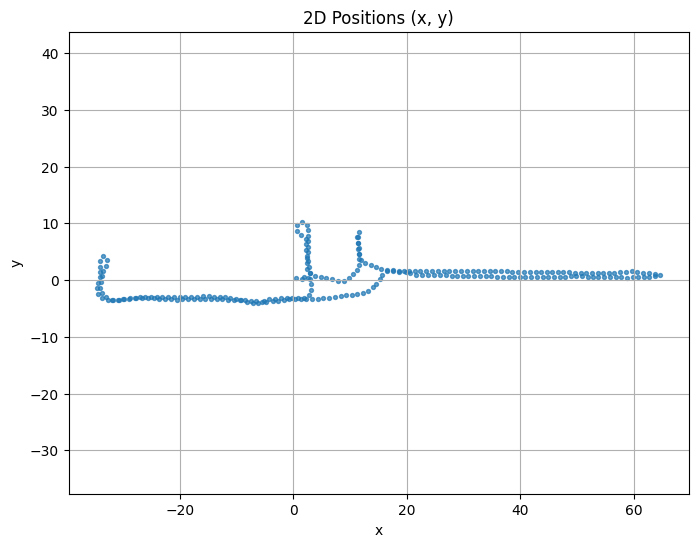

In [ ]:
def plot_xy_positions(df):
    """Plot 2D x-y positions from a DataFrame."""
    plt.figure(figsize=(8, 6))
    plt.scatter(df["x"], df["y"], s=8, alpha=0.7)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("2D Positions (x, y)")
    plt.axis("equal")
    plt.grid(True)
    plt.show()

plot_xy_positions(filtered_df)


In [ ]:
selected_indices = filtered_df.index.tolist()
print(f"selected {len(selected_indices)} indices, first 5: {selected_indices[:5]}")


selected 254 indices, first 5: [0, 1, 2, 3, 4]


## calculate descriptors for index

In [7]:
class MegaLocOPRModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = torch.hub.load("gmberton/MegaLoc", "get_trained_model")

    def forward(self, batch: dict[str, Tensor]) -> dict[str, Tensor]:
        key = next((k for k in batch if k.startswith("images_")), None)
        if key is None:
            raise KeyError("No key starting with 'images_' found in the batch.")
        images = batch[key]
        descriptor = self.model(images)
        output = {"final_descriptor": descriptor}
        return output


In [8]:
model = MegaLocOPRModel()
model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

Using cache found in /home/kartashov_ga/.cache/torch/hub/gmberton_MegaLoc_main
Using cache found in /home/kartashov_ga/.cache/torch/hub/facebookresearch_dinov2_main
/home/kartashov_ga/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/kartashov_ga/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/kartashov_ga/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


MegaLocOPRModel(
  (model): MegaLocModel(
    (backbone): DINOv2(
      (model): DinoVisionTransformer(
        (patch_embed): PatchEmbed(
          (proj): Conv2d(3, 768, kernel_size=(14, 14), stride=(14, 14))
          (norm): Identity()
        )
        (blocks): ModuleList(
          (0-11): 12 x NestedTensorBlock(
            (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
            (attn): MemEffAttention(
              (qkv): Linear(in_features=768, out_features=2304, bias=True)
              (proj): Linear(in_features=768, out_features=768, bias=True)
              (proj_drop): Dropout(p=0.0, inplace=False)
            )
            (ls1): LayerScale()
            (drop_path1): Identity()
            (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
            (mlp): Mlp(
              (fc1): Linear(in_features=768, out_features=3072, bias=True)
              (act): GELU(approximate='none')
              (fc2): Linear(in_features=3072, out_featur

In [9]:
from torchvision.transforms import functional as F

image_transform_fn = T.Compose([
    T.ToTensor(),
    T.Lambda(lambda x: F.rotate(x, -90)),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    T.Resize([322, 322], antialias=True)
])


In [10]:
def read_image(image_filepath: str | Path) -> Tensor:
    image = Image.open(image_filepath)
    image = image_transform_fn(image)
    return image


def to_batch(image: Tensor) -> dict[str, Tensor]:
    return {"images_0": image.unsqueeze(0)}

In [ ]:
from tqdm import tqdm

descriptors = []
for image_path in tqdm(db_df['path'][:10000]):
    image = read_image(image_path)
    batch = to_batch(image)
    batch = {k: v.to(device) for k, v in batch.items()}
    with torch.no_grad():
        desc = model(batch)
    descriptors.append(desc["final_descriptor"].cpu().numpy())
descriptors = np.concatenate(descriptors, axis=0)
np.save(root_data_dir / "descriptors.npy", descriptors)

print(f"Descriptors saved to {root_data_dir / 'descriptors.npy'}")


  2%|▏         | 156/10000 [00:06<06:43, 24.41it/s]


KeyboardInterrupt: 

In [ ]:
N, D = descriptors.shape
print(f"descriptors shape: {descriptors.shape}")

NameError: name 'descriptors' is not defined

## build FaissFlatIndex files

In [ ]:
# Build minimal FAISS index files for the filtered database and load FaissFlatIndex
import json
from opr.inference.index import FaissFlatIndex

index_dir = root_data_dir
cuted_df = db_df.iloc[:10000]

# Build meta.parquet with required columns. OPR expects pose = list of 7 floats (x,y,z,qx,qy,qz,qw) per row.
# We have no real poses; use dummy poses with scene_id in x so FaissFlatIndex.load() succeeds.
meta = pd.DataFrame({
    "idx": cuted_df.index.to_numpy(dtype=np.int64),
    "pose": [[float(sid), 0.0, 0.0, 0.0, 0.0, 0.0, 0.0] for sid in cuted_df["scene_id"]],
    "image_path": cuted_df["path"],
})
meta.to_parquet(index_dir / "meta.parquet")

# Minimal schema.json
schema = {"version": "1", "dim": D, "metric": "l2", "created_at": "26/02/2026", "opr_version": ""}
(index_dir / "schema.json").write_text(json.dumps(schema))

# Load the index
index = FaissFlatIndex.load(index_dir)
print(f"Index created at {index_dir}")
print(f"Index size: {index.size()}, dim: {index.dim()} metric: {index.metric()}")


NameError: name 'D' is not defined

# Test Localization Pipeline

This notebook tests the full localization pipeline:
- **SequencePlaceRecognitionPipeline** for image-based place recognition
- **RansacPointCloudRegistrationPipeline** for point cloud registration
- **LocalizationPipeline** combining both

We run inference on the first 100 queries from map2 and save sample outputs.


## 1. Setup and Imports


In [11]:
from __future__ import annotations

import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch import nn, Tensor
from torchvision import transforms as T
from PIL import Image
from tqdm.auto import tqdm

# Import from mmpr.inference (our new module)
from mmpr.inference import (
    FaissFlatIndex,
    PlaceRecognitionPipeline,
    SequencePlaceRecognitionPipeline,
    RansacPointCloudRegistrationPipeline,
    LocalizationPipeline,
    LocalizationResult,
    PointCloudStore,
)

# For loading query point clouds
from mmpr.data.pcd import SimplePCDLoader
from mmpr.data.transforms import get_T_map_to_world


In [12]:
# Output directory for results
OUTPUT_DIR = Path("/home/kartashov_ga/projects/tests/gsloc/26-02-26/")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Pipeline parameters
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
NUM_QUERIES = 10000  # Test on first 100 queries
MAX_WINDOW = 20    # Sequence window size
PER_FRAME_K = 10   # Top-k per frame for sequence PR
FINAL_K = 5        # Final top-k candidates for localization

# Validate paths
assert root_data_dir.exists(), f"Path {root_data_dir} does not exist"

print(f"Device: {DEVICE}")
print(f"Output Dir: {OUTPUT_DIR}")


Device: cuda
Output Dir: /home/kartashov_ga/projects/tests/gsloc/26-02-26


## 2. Load Model and Index


In [13]:
# Load the FAISS index from the database
index = FaissFlatIndex.load(root_data_dir)

print(f"Index loaded from {root_data_dir}")
print(f"  - Size: {index.size()} entries")
print(f"  - Dimension: {index.dim()}")
print(f"  - Metric: {index.metric()}")


Index loaded from /mnt/external_usb_hdd/6YL/Datasets/3RScan
  - Size: 10000 entries
  - Dimension: 8448
  - Metric: l2


## 3. Create Pipelines


In [14]:
# Create Place Recognition Pipeline (single-frame)
pr_pipeline = PlaceRecognitionPipeline(
    index=index,
    model=model,
    device=DEVICE,
)
print("PlaceRecognitionPipeline created")

# Create Sequence Place Recognition Pipeline
seq_pr_pipeline = SequencePlaceRecognitionPipeline(
    index=index,
    model=model,
    device=DEVICE,
    max_window=MAX_WINDOW,
    per_frame_k=PER_FRAME_K,
    final_k=FINAL_K,
    descriptor_agg="mean",
)
print(f"SequencePlaceRecognitionPipeline created (window={MAX_WINDOW}, per_frame_k={PER_FRAME_K}, final_k={FINAL_K})")

# # Create full Localization Pipeline
# # Note: LocalizationPipeline uses PlaceRecognitionPipeline, but works with SequencePR too
# loc_pipeline = LocalizationPipeline(
#     index=index,
#     place_recognition=pr_pipeline,  # Using single-frame PR for now
#     registration=reg_pipeline,
#     index_root=index_dir,
#     require_db_pointcloud=False,  # Skip candidates without point clouds
# )
# print("LocalizationPipeline created")


PlaceRecognitionPipeline created
SequencePlaceRecognitionPipeline created (window=20, per_frame_k=10, final_k=5)


## 4. Load Query Data


## 5. Run Inference


In [16]:
num_available = 10000

# Run localization on first NUM_QUERIES frames
results: list[LocalizationResult] = []
timing_stats: list[dict] = []
errors: list[dict] = []

print(f"Running localization on {num_available} queries...")
print(f"Using: LocalizationPipeline with PlaceRecognitionPipeline + RANSAC Registration")

for qi in tqdm(range(num_available), desc="Localizing"):
    # try:
    # Load query image
    image_path = q_df['path'][qi]
    
    if not Path(image_path).exists():
        errors.append({"query_idx": qi, "error": f"Image not found: {image_path}"})
        continue
    
    image = read_image(image_path)
    pr_input = to_batch(image)
    pr_input = {k: v.to(DEVICE) for k, v in pr_input.items()}
    
    
    # Run localization
    torch.cuda.synchronize() if DEVICE == "cuda" else None
    t_start = time.perf_counter()
    
    result = seq_pr_pipeline.infer(
        input_frame=pr_input,
        k=FINAL_K,
    )
    
    torch.cuda.synchronize() if DEVICE == "cuda" else None
    t_end = time.perf_counter()
    
    results.append(result)
    timing_stats.append({
        "query_idx": qi,
        "time_ms": (t_end - t_start) * 1000,
        # "chosen_idx": result.chosen_idx,
    })
        
    # except Exception as e:
    #     errors.append({"query_idx": qi, "error": str(e)})
    #     continue

print(f"\nCompleted: {len(results)} successful, {len(errors)} errors")


Running localization on 10000 queries...
Using: LocalizationPipeline with PlaceRecognitionPipeline + RANSAC Registration


Localizing:   0%|          | 0/10000 [00:00<?, ?it/s]

KeyboardInterrupt: 

# Sequence Place Recognition Benchmark Report

This report benchmarks the impact of sequence length (window size) across multiple maps. It shows per-map metrics over window sizes and overlays the cross-map mean. Aggregated mean and weighted-mean plots are also provided.


## Configuration

Paths, constants, and controls used throughout the report.


## Helpers

Utility functions to build PR caches and run the sequence benchmark sweep.


In [15]:
from __future__ import annotations
from typing import Iterable
import json
from pathlib import Path
from IPython.display import display
from tqdm import tqdm
from typing import Sequence

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

from mmpr.pr_infer import PRInferConfig, PRInferencer
from mmpr.seq_pr_benchmark import SequenceBenchmarkConfig, SequencePRBenchmarker

FORCE_RERUN = False

def build_pr_cache_for_map(map_name: str, q_df: pd.DataFrame) -> Path:
    """Build or load PR cache for a given map.

    Args:
        map_name: Map identifier such as "map2".
    Returns:
        Path to NPZ cache file.
    """
    pr_cache_path = Path(
        f"/home/kartashov_ga/projects/tests/gsloc/26-02-26/{map_name}.npz"
    )
    if pr_cache_path.exists() and not FORCE_RERUN:
        print(f"Using existing PR cache: {pr_cache_path}")
        return pr_cache_path

    cfg_inf = PRInferConfig(
        root_data_dir=root_data_dir,
        map_name=map_name,
        df=q_df,
        index_dir=root_data_dir,
        device=DEVICE,
        per_frame_k=PER_FRAME_K
    )
    PRInferencer(cfg_inf, model="megaloc").save(pr_cache_path)
    print(f"Built PR cache: {pr_cache_path}")
    return pr_cache_path


def _configs_match_json(d: dict, cfg: SequenceBenchmarkConfig) -> bool:
    """Return True if saved metrics.json config matches the benchmark config."""
    conf = d.get("config", {})
    try:
        return (
            int(conf.get("max_window", -1)) == int(cfg.max_window)
            and int(conf.get("per_frame_k_used", -1)) == int(cfg.per_frame_k_used)
            and int(conf.get("final_k", -1)) == int(cfg.final_k)
            and str(conf.get("recency_weighting", "")) == str(cfg.recency_weighting)
            and abs(float(conf.get("recall_threshold_m", -1.0)) - float(cfg.recall_threshold_m)) < 1e-9
        )
    except Exception:
        return False


def _row_from_metrics_json(d: dict, W: int, map_name: str) -> dict:
    """Convert metrics.json payload to a single summary row."""
    rk = d.get("recall_at_k", {}) or {}
    return {
        "w": int(W),
        "auc_pr": float(d.get("auc_pr", 0.0)),
        "f1_max": float(d.get("f1_max", 0.0)),
        "recall_at_1": float(rk.get("1", 0.0)),
        "recall_at_5": float(rk.get("5", 0.0)),
        "recall_at_10": float(rk.get("10", 0.0)),
        "recall_at_25": float(rk.get("25", 0.0)),
        "num_valid": int(d.get("num_queries_valid", 0)),
        "num_total": int(d.get("num_queries_total", 0)),
        "query_track": map_name,
    }


def run_sweep(
    q_df: pd.DataFrame,
    map_name: str,
    pr_cache_path: Path,
    seq_lengths: Iterable[int] = [MAX_WINDOW]
) -> pd.DataFrame:
    """Run or reuse sequence benchmark for a map across sequence lengths."""
    all_rows: list[dict] = []
    for W in tqdm(list(seq_lengths)):
        out_dir = OUTPUT_DIR / f"{map_name}_w{W:03d}"
        out_dir.mkdir(parents=True, exist_ok=True)
        cfg_b = SequenceBenchmarkConfig(
            q_df=q_df,
            db_index_dir=index_dir,
            cache_path=pr_cache_path,
            root_data_dir=root_data_dir,
            map_name=map_name,
            max_window=int(W),
            per_frame_k_used=PER_FRAME_K,
            final_k=FINAL_K,
            recency_weighting="none",
            recall_threshold_m=0.5,
        )
        # metrics_path = out_dir / "metrics.json"

        # if SKIP_IF_EXISTS and metrics_path.exists() and not FORCE_RERUN:
        #     try:
        #         d = json.loads(metrics_path.read_text())
        #         if _configs_match_json(d, cfg_b):
        #             all_rows.append(_row_from_metrics_json(d, W, map_name))
        #             continue
        #     except Exception:
        #         pass

        bench = SequencePRBenchmarker(cfg_b)
        artifacts = bench.run()
        bench.save(artifacts, out_dir)
        all_rows.append({
            "w": int(W),
            "auc_pr": float(artifacts.auc_pr),
            "f1_max": float(artifacts.f1_max),
            "recall_at_1": float(artifacts.recall_at_k.get(1, 0.0)),
            "recall_at_5": float(artifacts.recall_at_k.get(5, 0.0)),
            "recall_at_10": float(artifacts.recall_at_k.get(10, 0.0)),
            "recall_at_25": float(artifacts.recall_at_k.get(25, 0.0)),
            "num_valid": int(artifacts.num_queries_valid),
            "num_total": int(artifacts.num_queries_total),
            "query_track": map_name,
        })

    df = pd.DataFrame(all_rows).sort_values("w").reset_index(drop=True)
    return df


## Run Benchmarks

Build or reuse caches, run sweeps for each map, and store per-map and combined summaries.


In [24]:
# Run benchmarks for configured maps; save per-map and combined summaries
summaries: dict[str, pd.DataFrame] = {}
m = "first-10k-on-first-10k"

print(f"=== {m} ===")
cache_path = build_pr_cache_for_map(m, q_df[:10000])
df_m = run_sweep(q_df[:10000], m, cache_path, seq_lengths=list(range(1,21)))
summaries[m] = df_m
# Save per-map summary
out_map_dir = OUTPUT_DIR / m
out_map_dir.mkdir(parents=True, exist_ok=True)
(out_map_dir / "summary.csv").write_text(df_m.to_csv(index=False))

# Combined summary across maps
summary_all = pd.concat(list(summaries.values()), ignore_index=True)
(OUTPUT_DIR / "summary_all.csv").write_text(summary_all.to_csv(index=False))

display(summary_all.head(3))
display(summary_all.tail(3))


=== first-10k-on-first-10k ===
Using existing PR cache: /home/kartashov_ga/projects/tests/gsloc/26-02-26/first-10k-on-first-10k.npz


100%|██████████| 20/20 [01:27<00:00,  4.39s/it]


,w,auc_pr,f1_max,recall_at_1,recall_at_5,recall_at_10,recall_at_25,num_valid,num_total,query_track
0,1,0.825706,0.781251,0.6885,0.8441,0.8441,0.8441,10000,10000,first-10k-on-first-10k
1,2,0.830667,0.798812,0.7209,0.8709,0.8709,0.8709,10000,10000,first-10k-on-first-10k
2,3,0.834370,0.811627,0.7410,0.8891,0.8891,0.8891,10000,10000,first-10k-on-first-10k


,w,auc_pr,f1_max,recall_at_1,recall_at_5,recall_at_10,recall_at_25,num_valid,num_total,query_track
17,18,0.825915,0.866619,0.8073,0.9320,0.9320,0.9320,10000,10000,first-10k-on-first-10k
18,19,0.823808,0.866977,0.8071,0.9317,0.9317,0.9317,10000,10000,first-10k-on-first-10k
19,20,0.821658,0.867290,0.8069,0.9309,0.9309,0.9309,10000,10000,first-10k-on-first-10k


## Visualization helpers

In [25]:
def plot_metrics_vs_window_with_stats(
    summary_df,
    summary_all,
    metrics: Sequence[str] = ("auc_pr", "f1_max", "recall_at_1", "recall_at_5", "recall_at_10", "recall_at_25"),
):
    """Plot per-map metrics vs w and overlay cross-map mean and weighted mean.

    Args:
        summary_df: DataFrame for a single map (has columns 'w' and metrics).
        summary_all: Concatenated DataFrame across maps with columns 'w', 'query_track', 'num_valid', and metrics.
        metrics: metric names to visualize.
    Returns:
        dict metric -> plotly figure
    """
    figs = {}
    df = summary_df.sort_values("w").reset_index(drop=True)
    map_name = df["query_track"].iloc[0]
    # precompute simple mean once
    group = summary_all.groupby("w", as_index=False)
    mean_by_w = group[[m for m in metrics if m in summary_all.columns]].mean()

    for m in metrics:
        if m not in df.columns:
            continue
        fig = px.line(df, x="w", y=m, title=f"{map_name}: {m} vs sequence length (w)", markers=True)
        fig.update_layout(xaxis_title="sequence length (max_window)", yaxis_title=m)

        # Highlight maximum point on per-map line
        try:
            idx_max = df[m].astype(float).idxmax()
            w_star = int(df.loc[idx_max, "w"])  # sequence length at max
            y_star = float(df.loc[idx_max, m])
            fig.add_trace(
                go.Scatter(x=[w_star], y=[y_star], mode="markers", marker=dict(color="red", size=10), name="max", showlegend=False)
            )
            try:
                fig.add_vline(x=w_star, line_dash="dash", line_color="red")
            except Exception:
                fig.add_shape(type="line", x0=w_star, x1=w_star, y0=min(df[m].astype(float)), y1=max(df[m].astype(float)), line=dict(color="red", dash="dash"))
            fig.add_annotation(x=w_star, y=y_star, text=f"w={w_star}, {m}={y_star:.4f}", showarrow=True, arrowhead=2, ax=40, ay=-40)
        except Exception:
            pass

        # Overlay simple mean across maps
        if m in mean_by_w.columns:
            fig.add_trace(
                go.Scatter(
                    x=mean_by_w["w"],
                    y=mean_by_w[m].astype(float),
                    mode="lines",
                    name="mean",
                    line=dict(color="green", dash="dash"),
                    showlegend=True,
                )
            )

        # Overlay weighted mean across maps (weights = num_valid per map)
        try:
            wmean_series = (
                summary_all
                .groupby("w")
                .apply(lambda g: float(np.average(g[m].astype(float), weights=g["num_valid"].astype(float))), include_groups=False)
                .reset_index(name=m)
            )
            fig.add_trace(
                go.Scatter(
                    x=wmean_series["w"],
                    y=wmean_series[m].astype(float),
                    mode="lines",
                    name="weighted mean",
                    line=dict(color="purple", dash="dot"),
                    showlegend=True,
                )
            )
        except Exception:
            pass

        figs[m] = fig
        fig.show()
    return figs


In [26]:
def plot_aggregate_mean_median(
    summary_all,
    metrics: Sequence[str] = ("auc_pr", "f1_max", "recall_at_1", "recall_at_5", "recall_at_10", "recall_at_25"),
):
    """Draw separate figures that show only mean and weighted mean across maps, with maxima highlighted.

    Args:
        summary_all: Concatenated DataFrame across maps with columns 'w', 'query_track', 'num_valid', and metrics.
        metrics: metric names to visualize.
    Returns:
        dict metric -> plotly figure
    """
    figs = {}
    group = summary_all.groupby("w", as_index=False)
    mean_by_w = group[[m for m in metrics if m in summary_all.columns]].mean()
    # Weighted mean by num_valid
    def _weighted_series(g):
        return pd.Series({k: float(np.average(g[k].astype(float), weights=g["num_valid"].astype(float))) for k in metrics if k in g.columns})
    wmean_by_w = summary_all.groupby("w").apply(_weighted_series, include_groups=False).reset_index()

    for m in metrics:
        if m not in summary_all.columns:
            continue
        fig = go.Figure()
        # Mean line
        fig.add_trace(
            go.Scatter(
                x=mean_by_w["w"],
                y=mean_by_w[m].astype(float),
                mode="lines",
                name="mean",
                line=dict(color="green", dash="dash"),
                showlegend=True,
            )
        )
        # Weighted mean line
        if m in wmean_by_w.columns:
            fig.add_trace(
                go.Scatter(
                    x=wmean_by_w["w"],
                    y=wmean_by_w[m].astype(float),
                    mode="lines",
                    name="weighted mean",
                    line=dict(color="purple", dash="dot"),
                    showlegend=True,
                )
            )

        # Maxima on mean
        try:
            idx_mean_max = mean_by_w[m].astype(float).idxmax()
            w_mean_max = int(mean_by_w.loc[idx_mean_max, "w"])
            y_mean_max = float(mean_by_w.loc[idx_mean_max, m])
            fig.add_trace(
                go.Scatter(
                    x=[w_mean_max],
                    y=[y_mean_max],
                    mode="markers",
                    marker=dict(color="green", size=9, symbol="diamond"),
                    name="mean max",
                    showlegend=False,
                )
            )
            try:
                fig.add_vline(x=w_mean_max, line_dash="dash", line_color="green")
            except Exception:
                fig.add_shape(
                    type="line",
                    x0=w_mean_max,
                    x1=w_mean_max,
                    y0=min(mean_by_w[m].astype(float)),
                    y1=max(mean_by_w[m].astype(float)),
                    line=dict(color="green", dash="dash"),
                )
            fig.add_annotation(
                x=w_mean_max,
                y=y_mean_max,
                text=f"mean max: w={w_mean_max}, {m}={y_mean_max:.4f}",
                showarrow=True,
                arrowhead=2,
                ax=40,
                ay=-40,
            )
        except Exception:
            pass

        # Maxima on weighted mean
        try:
            idx_wmean_max = wmean_by_w[m].astype(float).idxmax()
            w_wmean_max = int(wmean_by_w.loc[idx_wmean_max, "w"])
            y_wmean_max = float(wmean_by_w.loc[idx_wmean_max, m])
            fig.add_trace(
                go.Scatter(
                    x=[w_wmean_max],
                    y=[y_wmean_max],
                    mode="markers",
                    marker=dict(color="purple", size=9, symbol="x"),
                    name="weighted mean max",
                    showlegend=False,
                )
            )
            try:
                fig.add_vline(x=w_wmean_max, line_dash="dot", line_color="purple")
            except Exception:
                fig.add_shape(
                    type="line",
                    x0=w_wmean_max,
                    x1=w_wmean_max,
                    y0=min(wmean_by_w[m].astype(float)),
                    y1=max(wmean_by_w[m].astype(float)),
                    line=dict(color="purple", dash="dot"),
                )
            fig.add_annotation(
                x=w_wmean_max,
                y=y_wmean_max,
                text=f"w-mean max: w={w_wmean_max}, {m}={y_wmean_max:.4f}",
                showarrow=True,
                arrowhead=2,
                ax=40,
                ay=-40,
            )
        except Exception:
            pass

        fig.update_layout(
            title=f"{m} (mean/weighted mean across maps) vs sequence length (w)",
            xaxis_title="sequence length (max_window)",
            yaxis_title=m,
        )
        figs[m] = fig
        fig.show()
    return figs


# Results

## Per-map values

In [27]:
# Compute and display aggregated stats, and draw overlays on plots for each map
metrics_cols = ("auc_pr", "f1_max", "recall_at_1", "recall_at_5", "recall_at_10", "recall_at_25")
summary_mean_by_w = summary_all.groupby("w")[list(metrics_cols)].mean().reset_index()
summary_weighted_mean_by_w = (
    summary_all
    .groupby("w")
    .apply(lambda g: pd.Series({k: float(np.average(g[k].astype(float), weights=g["num_valid"].astype(float))) for k in metrics_cols}), include_groups=False)
    .reset_index()
)

# Render plots, overlaying mean and weighted mean across all maps
for mname, df_map in summaries.items():
    print(f"\n=== {mname}: mean and weighted-mean overlays ===")
    display(df_map.head(30))
    plot_metrics_vs_window_with_stats(df_map, summary_all)



=== first-10k-on-first-10k: mean and weighted-mean overlays ===


,w,auc_pr,f1_max,recall_at_1,recall_at_5,recall_at_10,recall_at_25,num_valid,num_total,query_track
0,1,0.825706,0.781251,0.6885,0.8441,0.8441,0.8441,10000,10000,first-10k-on-first-10k
1,2,0.830667,0.798812,0.7209,0.8709,0.8709,0.8709,10000,10000,first-10k-on-first-10k
2,3,0.834370,0.811627,0.7410,0.8891,0.8891,0.8891,10000,10000,first-10k-on-first-10k
3,4,0.836832,0.822245,0.7555,0.8985,0.8985,0.8985,10000,10000,first-10k-on-first-10k
4,5,0.837916,0.830081,0.7664,0.9065,0.9065,0.9065,10000,10000,first-10k-on-first-10k
5,6,0.838412,0.836625,0.7766,0.9138,0.9138,0.9138,10000,10000,first-10k-on-first-10k
6,7,0.838538,0.842698,0.7858,0.9172,0.9172,0.9172,10000,10000,first-10k-on-first-10k
7,8,0.838260,0.847358,0.7924,0.9194,0.9194,0.9194,10000,10000,first-10k-on-first-10k
8,9,0.837734,0.851079,0.7963,0.9211,0.9211,0.9211,10000,10000,first-10k-on-first-10k
9,10,0.836767,0.854423,0.7992,0.9228,0.9228,0.9228,10000,10000,first-10k-on-first-10k


## Aggregated values

In [ ]:
# Display aggregated tables (mean and weighted-mean)
display(summary_mean_by_w.head(30))
try:
    display(summary_weighted_mean_by_w.head(30))
except Exception:
    pass

# Aggregate-only plots (mean and weighted mean across maps) with maxima
plot_aggregate_mean_median(summary_all);


,w,auc_pr,f1_max,recall_at_1,recall_at_5,recall_at_10,recall_at_25
0,1,0.808033,0.69819,0.821244,0.869429,0.895379,0.926725
1,2,0.811610,0.70181,0.824181,0.872254,0.896309,0.926885


,w,auc_pr,f1_max,recall_at_1,recall_at_5,recall_at_10,recall_at_25
0,1,0.799818,0.690543,0.813608,0.868479,0.896336,0.930103
1,2,0.803362,0.694037,0.816985,0.872193,0.897687,0.930103


In [ ]:
# Timing statistics
if timing_stats:
    times = [s["time_ms"] for s in timing_stats]
    print(f"Timing Statistics (ms):")
    print(f"  Mean: {np.mean(times):.2f}")
    print(f"  Std:  {np.std(times):.2f}")
    print(f"  Min:  {np.min(times):.2f}")
    print(f"  Max:  {np.max(times):.2f}")
    print(f"  Median: {np.median(times):.2f}")


Timing Statistics (ms):
  Mean: 448.14
  Std:  136.96
  Min:  337.07
  Max:  1164.98
  Median: 393.15


## 6. Save Results


In [ ]:
# Create output subdirectory for this run
run_dir = OUTPUT_DIR / f"run_{time.strftime('%Y%m%d_%H%M%S')}"
run_dir.mkdir(parents=True, exist_ok=True)
results_dir = run_dir / "localization_results"
results_dir.mkdir(exist_ok=True)

# Save individual LocalizationResults as JSON
print(f"Saving {len(results)} localization results to {results_dir}")
for i, result in enumerate(results):
    result_path = results_dir / f"result_{i:04d}.json"
    result.save(result_path)

# Save timing statistics
timing_df = pd.DataFrame(timing_stats)
timing_path = run_dir / "timing_stats.csv"
timing_df.to_csv(timing_path, index=False)
print(f"Timing stats saved to {timing_path}")

# Save errors
if errors:
    errors_path = run_dir / "errors.json"
    errors_path.write_text(json.dumps(errors, indent=2))
    print(f"Errors saved to {errors_path}")

# Save summary
summary = {
    "num_queries": num_available,
    "num_successful": len(results),
    "num_errors": len(errors),
    "config": {
        "device": DEVICE,
        "max_window": MAX_WINDOW,
        "per_frame_k": PER_FRAME_K,
        "final_k": FINAL_K,
        "voxel_size": VOXEL_SIZE,
    },
    "timing_ms": {
        "mean": float(np.mean(times)) if timing_stats else None,
        "std": float(np.std(times)) if timing_stats else None,
        "min": float(np.min(times)) if timing_stats else None,
        "max": float(np.max(times)) if timing_stats else None,
        "median": float(np.median(times)) if timing_stats else None,
    },
    "db_map": str(DB_MAP_DIR),
    "query_map": str(QUERY_MAP_DIR),
}
summary_path = run_dir / "summary.json"
summary_path.write_text(json.dumps(summary, indent=2))
print(f"Summary saved to {summary_path}")

print(f"\n=== All outputs saved to {run_dir} ===")


Saving 100 localization results to /home/kartashov_ga/projects/mmpr/multimodal-place-recognition/experiments/localization_test_ITLP/run_20260129_052828/localization_results
Timing stats saved to /home/kartashov_ga/projects/mmpr/multimodal-place-recognition/experiments/localization_test_ITLP/run_20260129_052828/timing_stats.csv
Summary saved to /home/kartashov_ga/projects/mmpr/multimodal-place-recognition/experiments/localization_test_ITLP/run_20260129_052828/summary.json

=== All outputs saved to /home/kartashov_ga/projects/mmpr/multimodal-place-recognition/experiments/localization_test_ITLP/run_20260129_052828 ===


In [ ]:
# Verify we can load the saved results back
if results:
    sample_path = results_dir / "result_0000.json"
    loaded_result = LocalizationResult.load(sample_path)
    
    print("Sample loaded result:")
    print(f"  Version: {loaded_result.version}")
    print(f"  Chosen idx: {loaded_result.chosen_idx}")
    print(f"  Num candidates: {len(loaded_result.candidates)}")
    
    if loaded_result.candidates:
        c = loaded_result.candidates[0]
        print(f"  First candidate:")
        print(f"    - idx: {c.idx}")
        print(f"    - pr_distance: {c.pr_distance:.4f}")
        print(f"    - db_pose: {c.db_pose}")
        print(f"    - estimated_pose: {c.estimated_pose}")
        print(f"    - registration_confidence: {c.registration_confidence}")


Sample loaded result:
  Version: 1
  Chosen idx: 1
  Num candidates: 5
  First candidate:
    - idx: 1
    - pr_distance: 0.8563
    - db_pose: [ 2.8301377e+00  2.3973840e-01  1.0006523e+02 -3.3749759e-03
 -8.5756257e-03 -4.7583514e-01  8.7948620e-01]
    - estimated_pose: [ 1.67879717e+00  3.29604477e-01  1.00392214e+02  1.84206487e-02
  5.83162265e-03 -4.17665298e-01  9.08395493e-01]
    - registration_confidence: 1.0


## 7. (Optional) Test Sequence Place Recognition Separately


In [ ]:
# Test the SequencePlaceRecognitionPipeline separately
print("Testing SequencePlaceRecognitionPipeline on first 10 frames...")

# Reset sequence state
seq_pr_pipeline.reset()

seq_results = []
for qi in range(min(10, num_available)):
    image_path = query_images_dir / f"{qi:06d}.jpg"
    if not image_path.exists():
        image_path = query_images_dir / f"{qi:06d}.png"
    
    if image_path.exists():
        image = read_image(image_path)
        pr_input = to_batch(image)
        pr_input = {k: v.to(DEVICE) for k, v in pr_input.items()}
        
        result = seq_pr_pipeline.infer(input_frame=pr_input, k=5)
        seq_results.append(result)
        
        print(f"Frame {qi}: top-5 db_idx = {result.db_idx.tolist() if result.db_idx is not None else 'N/A'}")

# Save sample sequence PR result
if seq_results:
    sample_pr_path = run_dir / "sample_sequence_pr_result.json"
    seq_results[-1].save(sample_pr_path)
    print(f"\nSample SequencePR result saved to {sample_pr_path}")


In [ ]:
print("=" * 60)
print("LOCALIZATION PIPELINE TEST COMPLETE")
print("=" * 60)
print(f"Results directory: {run_dir}")
print(f"Total queries processed: {len(results)}")
print(f"Errors encountered: {len(errors)}")
